# I-VAE for muon tomography

In [ ]:
from tqdm import tqdm
import numpy as np
import torch
import random
import sys
import os
import time
sys.path.append(os.path.abspath("../python"))

from prior import load_datasets
from precompute import precompute_muon_obs
from plotting import disable_axes, plot_state, plot_prior, plot_belief, plot_obs, plot_obs_surrogate, plot_simulation_error, plot_belief_over_time, plot_qualitative, animate_belief_updates, create_animation
from surrogate import load_obs_model
from belief_updater import load_muon_ivae

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
from matplotlib.colors import LinearSegmentedColormap

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Use Latin Modern instead
    "font.size": 12,
    "mathtext.fontset": "stix", # "cm"
})

plt.style.use('dark_background')
colors = ["#44342a", "#e1e697"]  # Dark brown to tan (#3E1F00 to #D2B48C)
cmap = LinearSegmentedColormap.from_list("brown_to_tan", colors, N=256)

## Prior data

In [3]:
x_train, x_train3d, x_test, x_test3d = load_datasets()

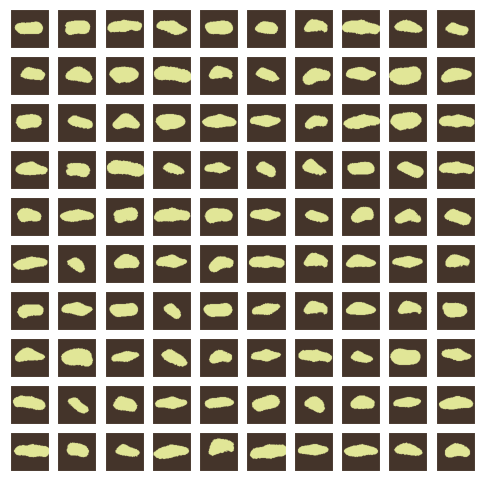

In [68]:
plot_prior(x_train)

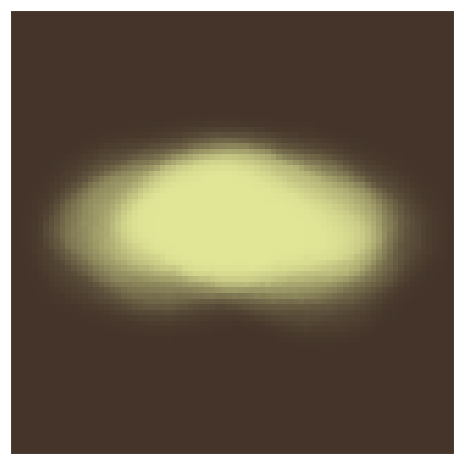

In [69]:
plot_belief(x_train, isnp=True)

## Muon observations (precomputed)

In [7]:
PRECOMPUTED_MUON, PRECOMPUTED_MUON_TEST = precompute_muon_obs(
    obs_model=None,
    x_train=x_train,
    x_train3d=x_train3d,
    x_test=x_test,
    x_test3d=x_test3d)

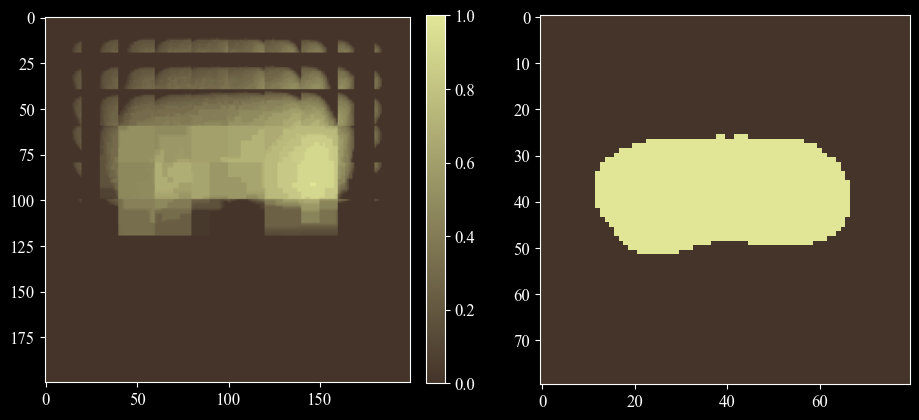

In [8]:
plot_obs(x_test, PRECOMPUTED_MUON_TEST, test_idx=2)

## Muon surrogate model

In [9]:
device = 'cuda:0'

In [10]:
obs_model_path = '../models/obs_model.pth'
obs_model = load_obs_model(model_path=obs_model_path, device=device)

## I-VAE belief update model

In [13]:
model_path = '../models/ivae.pth'
model = load_muon_ivae(model_path, device=device)

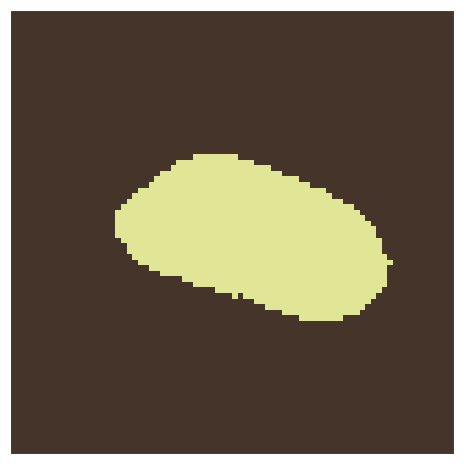

In [70]:
o = torch.full((1,1,200,200), -1).float().to(device)
b = model.sample(o)
plot_state(b.detach().cpu())

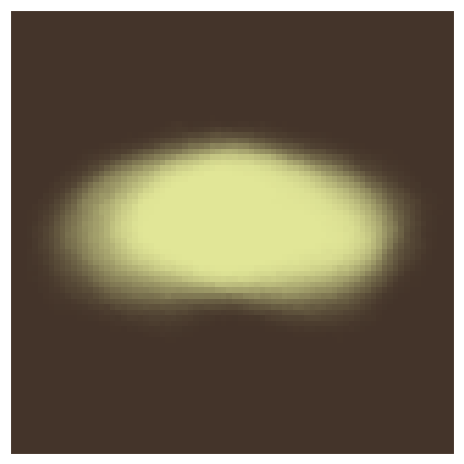

In [71]:
o = torch.full((1,1,200,200), -1.0).to(device)
b = model.update(o)
S = model.sample(b, m=1000)
plot_belief(S)

## POMDP

In [ ]:
from pomdp import MuonPOMDP, State, generate_true_state, calc_mass_center
from policies import simulate

In [17]:
mass_center = calc_mass_center(x_train)

In [18]:
pomdp = MuonPOMDP(
    belief_updater=model,
    obs_surrogate=obs_model,
    muon_data=PRECOMPUTED_MUON,
    muon_test_data=PRECOMPUTED_MUON_TEST,
    mass_center=mass_center)

## Simulation

In [19]:
test_idx = 59
test_state = generate_true_state(x_test, idx=test_idx)[0]
state_obj = State(test_state, idx=test_idx)

delta = np.inf
m = 100

info        = simulate(pomdp, state_obj, delta=delta, progress=True, m=m, seed=test_idx, nsteps=1)
info_oracle = simulate(pomdp, state_obj, delta=delta, progress=True, m=m, seed=test_idx, oracle_policy=True)
info_rand   = simulate(pomdp, state_obj, delta=delta, progress=True, m=m, seed=test_idx, rand_policy=True)

 99%|█████████▉| 100/101 [00:00<00:00, 114.92it/s]


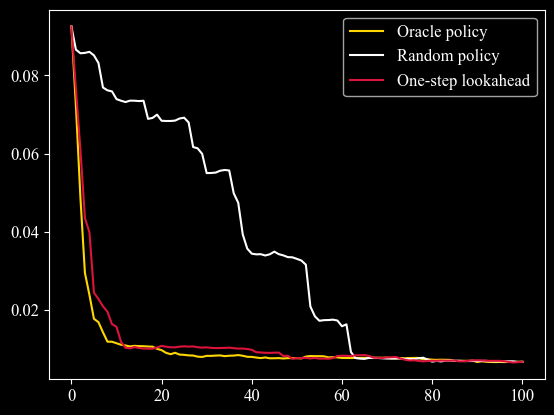

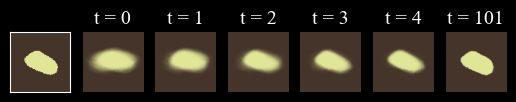

In [20]:
plot_simulation_error(
    [info_oracle, info_rand, info],
    ['Oracle policy', 'Random policy', 'One-step lookahead'],
    ['gold', 'white', 'crimson'])

beliefs = info['beliefs']
plot_belief_over_time(beliefs, test_state)

In [21]:
plot_qualitative(pomdp, info, state_obj)

-285.21667
-288.40228 ± 18.93


## Animation

In [22]:
frames = animate_belief_updates(pomdp, x_test, idx=22)
create_animation(frames, output_name="qualitative-belief.mp4", fps=10)

 99%|█████████▉| 100/101 [00:03<00:00, 28.89it/s]


<video style="max-width: 100%; height: auto;" controls>
    <source src="qualitative-belief.mp4" type="video/mp4">
    Your browser does not support the video tag.
</video>

### State

-285.2166748046875
False


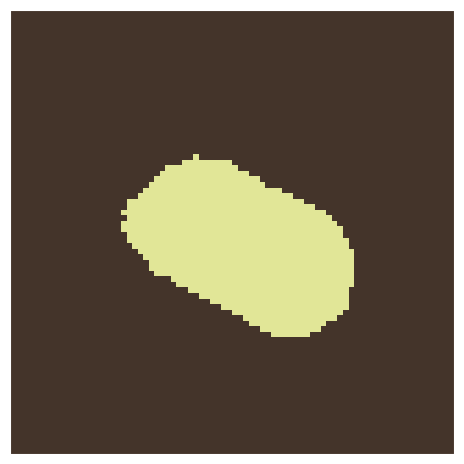

In [72]:
s, _ = generate_true_state(x_test, idx=1)
print(torch.sum(s).item() - mass_center)
print(torch.sum(s).item() > mass_center)
plot_state(s)

## Observation model

Truth: -9.217
Belief: 33.13 ± 21.56


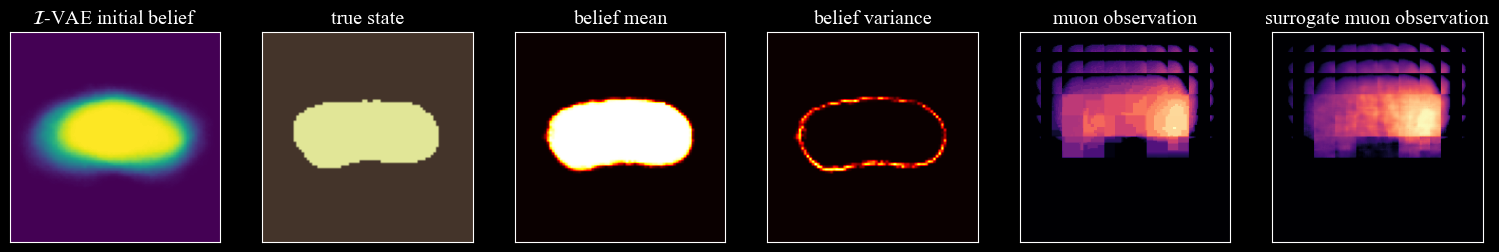

In [24]:
plot_obs_surrogate(obs_model, model, x_test, x_test3d, PRECOMPUTED_MUON, PRECOMPUTED_MUON_TEST, mass_center=mass_center, print_stats=True)